In [22]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
df = pd.read_csv('Dataset.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [23]:
df.shape


(301, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [ ]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [ ]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [ ]:
df['Owner'].unique()

array([0, 1, 3])

In [ ]:
df['Selling_type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [ ]:
df['Car_Name'].nunique()

98

<Axes: xlabel='Selling_Price', ylabel='Count'>

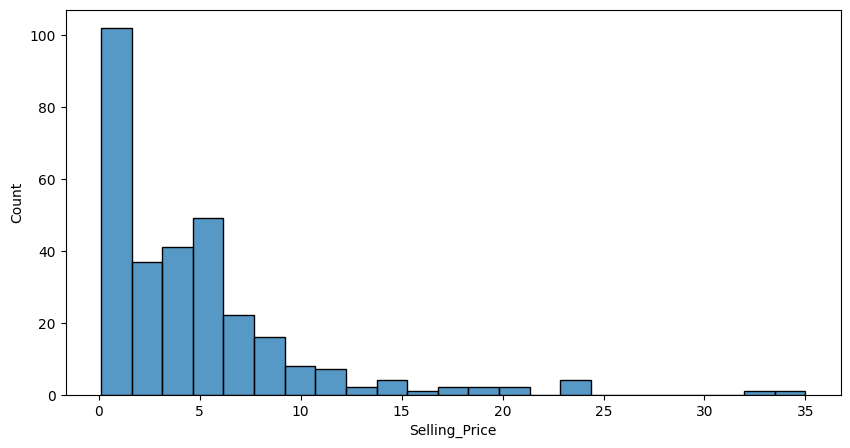

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Selling_Price'])

In [ ]:
df['Selling_Price'].describe()

,Selling_Price
count,301.000000
mean,4.661296
std,5.082812
min,0.100000
25%,0.900000
50%,3.600000
75%,6.000000
max,35.000000


##Observation

The selling price distribution is positively skewed. Most vehicles are priced below ₹6 lakh, while a small number of high-priced vehicles (up to ₹35 lakh) create a long right tail. The mean selling price is higher than the median, indicating the presence of expensive outlier vehicles

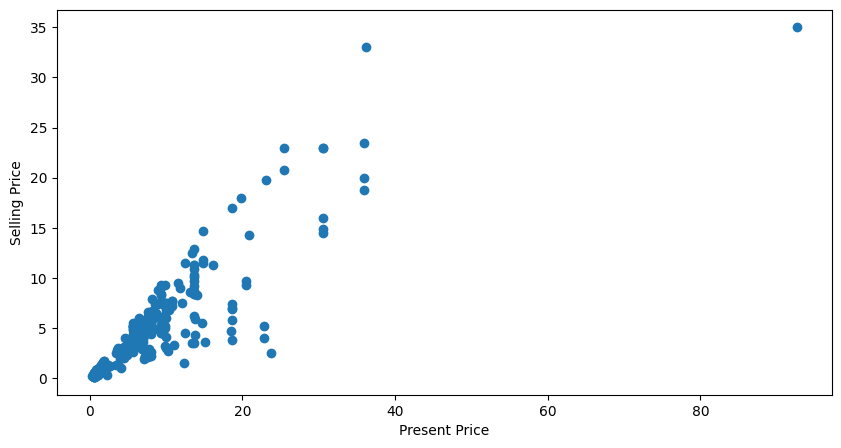

In [6]:
plt.figure(figsize=(10,5))

plt.scatter(
    df['Present_Price'],
    df['Selling_Price']
)

plt.xlabel('Present Price')
plt.ylabel('Selling Price')

plt.show()

A strong positive relationship exists between Present Price and Selling Price. Cars with higher showroom prices tend to have higher resale values. Present Price appears to be one of the most influential factors affecting car price prediction.

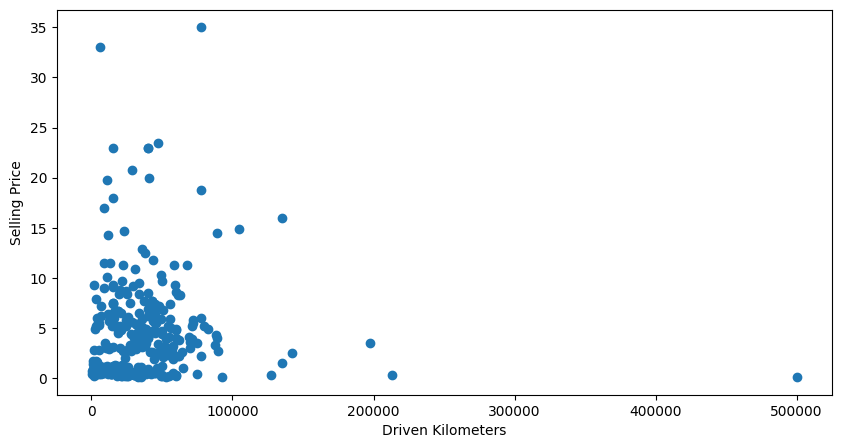

In [16]:
plt.figure(figsize=(10,5))
plt.scatter(
    df['Driven_kms'],
    df['Selling_Price']
)
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')
plt.show()

A strong positive relationship exists between Present Price and Selling Price. Cars with higher showroom prices tend to have higher resale values. Present Price appears to be one of the most influential factors affecting car price prediction.

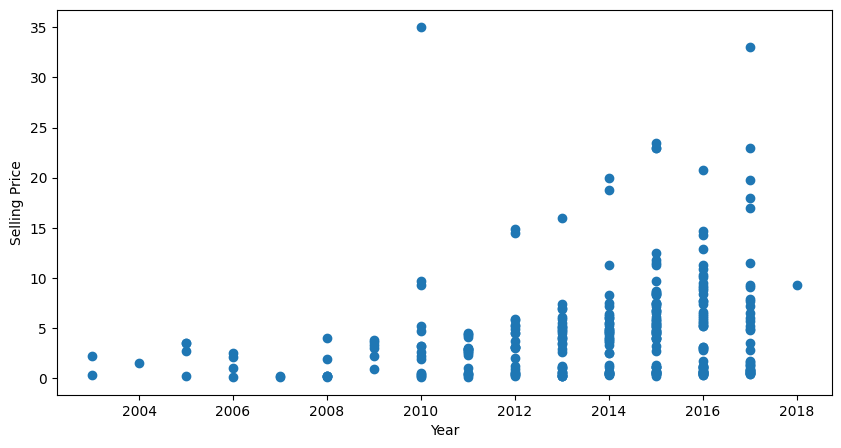

In [17]:
plt.figure(figsize=(10,5))

plt.scatter(
    df['Year'],
    df['Selling_Price']
)
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

Newer vehicles generally have higher selling prices than older vehicles. Selling Price increases with manufacturing year, indicating that vehicle age plays a significant role in determining resale value.

<Axes: title={'center': 'Correlation Heatmap'}>

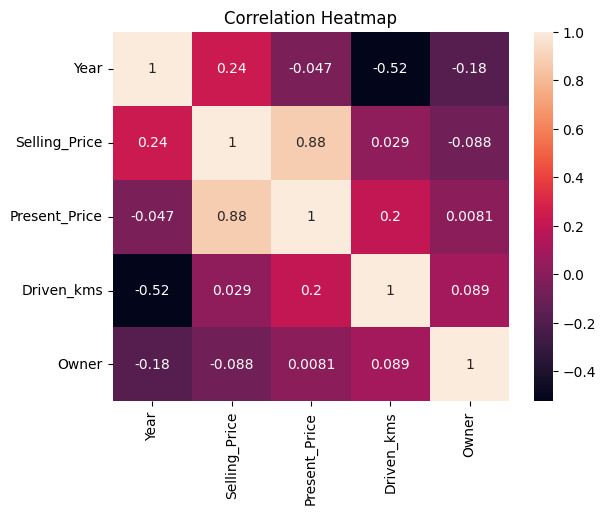

In [27]:
corr= df.corr(numeric_only=True)
plt.title("Correlation Heatmap")
sns.heatmap(
    corr,
    annot = True
)
plt.show()

<Axes: xlabel='Fuel_Type', ylabel='count'>

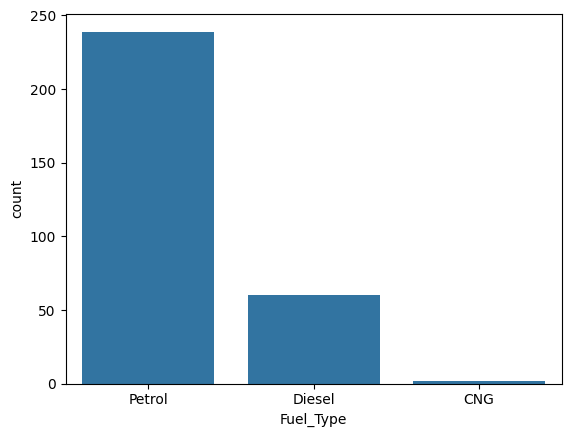

In [31]:
sns.countplot(data=df,x='Fuel_Type')
plt.show()

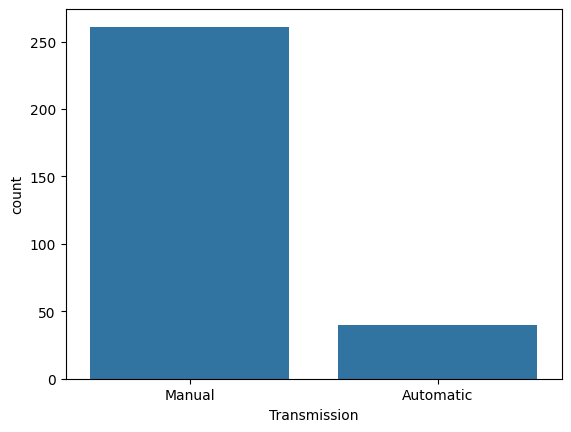

In [38]:
sns.countplot(data=df,x='Transmission')
plt.show()

<Axes: xlabel='Selling_type', ylabel='count'>

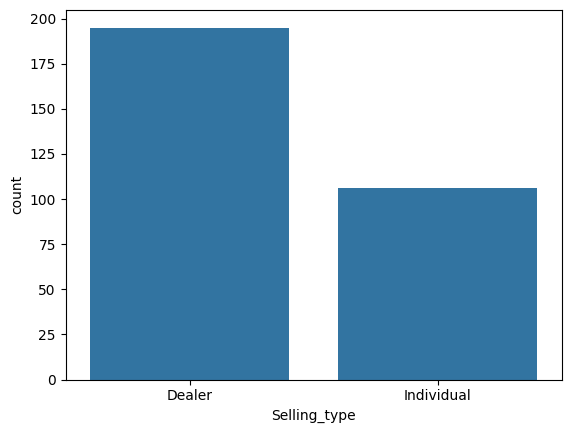

In [36]:
sns.countplot(data=df,x='Selling_type')
plt.show()

<Axes: xlabel='Fuel_Type', ylabel='Selling_Price'>

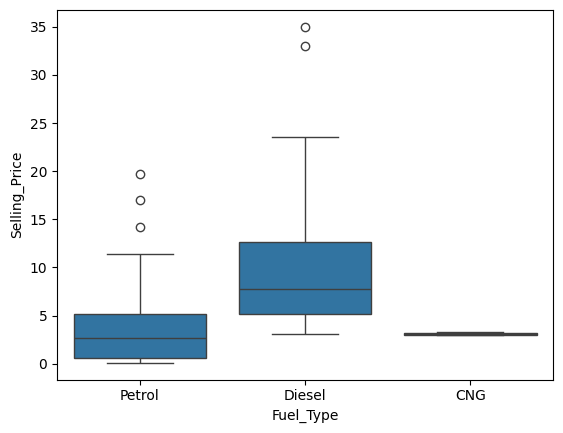

In [37]:
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")
plt.show()

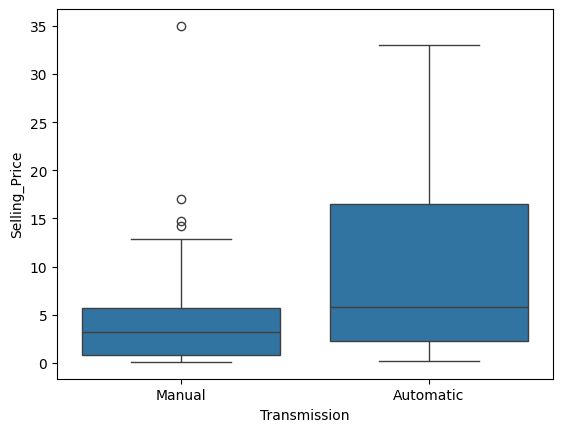

In [39]:
sns.boxplot(data=df, x="Transmission", y="Selling_Price")
plt.show()

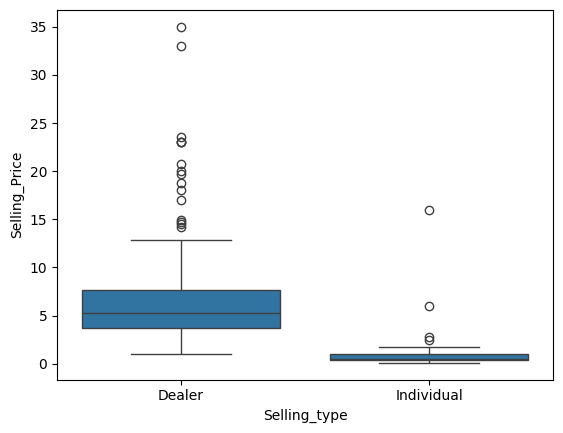

In [42]:
sns.boxplot(data=df, x= "Selling_type", y= "Selling_Price")
plt.show()

In [6]:
df['Car_Age'] = 2026 - df['Year']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [6]:
df = df.drop(columns=['Car_Name'])
df = df.drop(columns=['Year'])
df.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  301 non-null    float64
 1   Present_Price  301 non-null    float64
 2   Driven_kms     301 non-null    int64  
 3   Fuel_Type      301 non-null    object 
 4   Selling_type   301 non-null    object 
 5   Transmission   301 non-null    object 
 6   Owner          301 non-null    int64  
 7   Car_Age        301 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.9+ KB


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Selling_Price            301 non-null    float64
 1   Present_Price            301 non-null    float64
 2   Driven_kms               301 non-null    int64  
 3   Owner                    301 non-null    int64  
 4   Fuel_Type_Diesel         301 non-null    bool   
 5   Fuel_Type_Petrol         301 non-null    bool   
 6   Selling_type_Individual  301 non-null    bool   
 7   Transmission_Manual      301 non-null    bool   
dtypes: bool(4), float64(2), int64(2)
memory usage: 10.7 KB


In [9]:
y = df['Selling_Price']
X = df.drop('Selling_Price', axis=1)
X.head()

,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,False,True,False,True
1,9.54,43000,0,True,False,False,True
2,9.85,6900,0,False,True,False,True
3,4.15,5200,0,False,True,False,True
4,6.87,42450,0,True,False,False,True


In [10]:
y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(240, 7)
(61, 7)
(240,)
(61,)


In [16]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
y_pred = model.predict(X_test)
print(y_pred[:5])

[ 0.2618 11.2242  5.4385  0.2226  8.3559]


In [19]:
print(y_test[:5])

177     0.35
289    10.11
228     4.95
198     0.15
60      6.95
Name: Selling_Price, dtype: float64


In [20]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9231063690264224

In [26]:
pd.DataFrame({
    'Actual Selling Price': y_pred,
    'Predicted Selling Price': y_test
})

,Actual Selling Price,Predicted Selling Price
177,0.26180,0.35
289,11.22420,10.11
228,5.43850,4.95
198,0.22260,0.15
60,8.35590,6.95
...,...,...
234,5.13850,5.50
296,8.24795,9.50
281,4.11900,2.10
285,7.05600,7.40


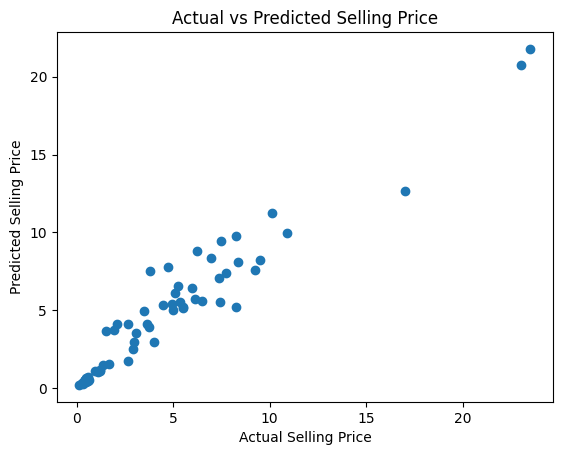

In [25]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.show()

In [27]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,Present_Price,0.885749
1,Driven_kms,0.084973
6,Transmission_Manual,0.013947
4,Fuel_Type_Petrol,0.005706
3,Fuel_Type_Diesel,0.004920
5,Selling_type_Individual,0.002918
2,Owner,0.001789


In [28]:
import pickle

pickle.dump(model, open("car_price_model.pkl", "wb"))